<a href="https://colab.research.google.com/github/DrAthilakshmi/HISTNet-model/blob/main/HISTNet_BreakHis_5fold_test_accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# STEP 1: DOWNLOAD BREAKHIS DATASET (Fixed & Automated)
# =========================================================
import os
import json

# 1. Install Kaggle Library
!pip install -q kaggle

# 2. Create kaggle.json automatically using the keys you provided
# (This replaces the manual file upload step)
kaggle_creds = {"username":"","key":""}

with open('kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# 3. Setup Kaggle Config
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Download Dataset
# We download the specific BreaKHis archive
print("⏳ Downloading BreaKHis Dataset...")
!kaggle datasets download -d ambarish/breakhis -p /content/breakhis_raw

# 5. Unzip
print("⏳ Unzipping (This might take a moment)...")
!unzip -q /content/breakhis_raw/breakhis.zip -d /content/breakhis_data
print("✅ Download & Unzip Complete.")

⏳ Downloading BreaKHis Dataset...
Dataset URL: https://www.kaggle.com/datasets/ambarish/breakhis
License(s): unknown
100% 3.97G/3.99G [00:36<00:00, 133MB/s]
100% 3.99G/3.99G [00:36<00:00, 117MB/s]
⏳ Unzipping (This might take a moment)...
✅ Download & Unzip Complete.


In [ ]:
# =========================================================
# STEP 2: ORGANIZE BREAKHIS DATA (400X MAGNIFICATION)
# =========================================================
import os
import shutil
import glob
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 1. Configuration
# The unzip usually creates this path. Adjust if your 'unzip' output was different.
SOURCE_ROOT = "/content/breakhis_data/BreaKHis_v1"
DEST_ROOT = "/content/BreaKHis_Processed"
MAGNIFICATION = "400X" # We use 400X for best detail. Options: 40X, 100X, 200X, 400X
CLASSES = ["benign", "malignant"]

# 2. Create Destination Folders
for split in ["train", "val"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(DEST_ROOT, split, cls), exist_ok=True)

print(f"🚀 Organizing BreaKHis ({MAGNIFICATION}) data into '{DEST_ROOT}'...")

# 3. Collect File Paths
all_images = []
all_labels = []

# BreaKHis structure is nested. We use recursive glob to find images.
# Example path: .../histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549AB/400X/SOB_B_A...png
print("⏳ Scanning files...")
for cls in CLASSES:
    # Search specifically for the magnification folder
    search_pattern = os.path.join(SOURCE_ROOT, "**", MAGNIFICATION, "*.png")
    images = glob.glob(search_pattern, recursive=True)

    # Filter: ensure the image actually belongs to the current class (benign/malignant)
    # The class name is always part of the folder path in BreaKHis
    cls_images = [img for img in images if f"/{cls}/" in img.lower() or f"\\{cls}\\" in img.lower()]

    print(f"   Found {len(cls_images)} images for class: {cls}")

    for img in cls_images:
        all_images.append(img)
        all_labels.append(cls)

# 4. Split Data (80% Train, 20% Validation)
if len(all_images) == 0:
    print("❌ Error: No images found! Check the SOURCE_ROOT path.")
else:
    X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels)

    # 5. Copy Files
    def copy_files(files, labels, split):
        for src, label in tqdm(zip(files, labels), total=len(files), desc=f"Copying {split}"):
            fname = os.path.basename(src)
            dst = os.path.join(DEST_ROOT, split, label, fname)
            shutil.copy(src, dst)

    copy_files(X_train, y_train, "train")
    copy_files(X_val, y_val, "val")

    print(f"\n✅ Data Organization Complete! Ready for loading.")

🚀 Organizing BreaKHis (400X) data into '/content/BreaKHis_Processed'...
⏳ Scanning files...
   Found 588 images for class: benign
   Found 1232 images for class: malignant


Copying val: 100%|██████████| 364/364 [00:01<00:00, 347.42it/s]


✅ Data Organization Complete! Ready for loading.


In [ ]:
# =========================================================
# STEP 2: ORGANIZE BREAKHIS DATA (400X MAGNIFICATION)
# =========================================================
import os
import shutil
import glob
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 1. Configuration
# The unzip usually creates this path. Adjust if your 'unzip' output was different.
SOURCE_ROOT = "/content/breakhis_data/BreaKHis_v1"
DEST_ROOT = "/content/BreaKHis_Processed"
MAGNIFICATION = "400X" # We use 400X for best detail. Options: 40X, 100X, 200X, 400X
CLASSES = ["benign", "malignant"]

# 2. Create Destination Folders
for split in ["train", "val"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(DEST_ROOT, split, cls), exist_ok=True)

print(f"🚀 Organizing BreaKHis ({MAGNIFICATION}) data into '{DEST_ROOT}'...")

# 3. Collect File Paths
all_images = []
all_labels = []

# BreaKHis structure is nested. We use recursive glob to find images.
# Example path: .../histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549AB/400X/SOB_B_A...png
print("⏳ Scanning files...")
for cls in CLASSES:
    # Search specifically for the magnification folder
    search_pattern = os.path.join(SOURCE_ROOT, "**", MAGNIFICATION, "*.png")
    images = glob.glob(search_pattern, recursive=True)

    # Filter: ensure the image actually belongs to the current class (benign/malignant)
    # The class name is always part of the folder path in BreaKHis
    cls_images = [img for img in images if f"/{cls}/" in img.lower() or f"\\{cls}\\" in img.lower()]

    print(f"   Found {len(cls_images)} images for class: {cls}")

    for img in cls_images:
        all_images.append(img)
        all_labels.append(cls)

# 4. Split Data (80% Train, 20% Validation)
if len(all_images) == 0:
    print("❌ Error: No images found! Check the SOURCE_ROOT path.")
else:
    X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels)

    # 5. Copy Files
    def copy_files(files, labels, split):
        for src, label in tqdm(zip(files, labels), total=len(files), desc=f"Copying {split}"):
            fname = os.path.basename(src)
            dst = os.path.join(DEST_ROOT, split, label, fname)
            shutil.copy(src, dst)

    copy_files(X_train, y_train, "train")
    copy_files(X_val, y_val, "val")

    print(f"\n✅ Data Organization Complete! Ready for loading.")

🚀 Organizing BreaKHis (400X) data into '/content/BreaKHis_Processed'...
⏳ Scanning files...
   Found 588 images for class: benign
   Found 1232 images for class: malignant


Copying val: 100%|██████████| 364/364 [00:02<00:00, 136.13it/s]


✅ Data Organization Complete! Ready for loading.


In [ ]:
# =========================================================
# STEP 3: BALANCE TRAINING DATA VIA AUGMENTATION
# =========================================================
import os
import random
from glob import glob
from PIL import Image, ImageOps
from tqdm import tqdm

# 1. Define Paths to Training Folders
TRAIN_BENIGN_DIR = "/content/BreaKHis_Processed/train/benign"
TRAIN_MALIGNANT_DIR = "/content/BreaKHis_Processed/train/malignant"

# 2. Get Current Training Counts
benign_images = glob(os.path.join(TRAIN_BENIGN_DIR, "*.png"))
malignant_images = glob(os.path.join(TRAIN_MALIGNANT_DIR, "*.png"))

num_benign = len(benign_images)
num_malignant = len(malignant_images)

print(f"📊 Before Augmentation:")
print(f"   Train Benign: {num_benign}")
print(f"   Train Malignant: {num_malignant}")

# Calculate how many new images are needed
images_to_generate = num_malignant - num_benign

if images_to_generate <= 0:
    print("\n✅ Benign class is already balanced or in the majority!")
else:
    print(f"\n⚙️ Generating {images_to_generate} augmented benign images...")

    # 3. Define Safe Augmentations
    # Flips and strict 90-degree rotations are safe for histopathology
    # because they don't distort the cellular structures.
    def augment_image(img):
        # Random Horizontal Flip
        if random.choice([True, False]):
            img = ImageOps.mirror(img)

        # Random Vertical Flip
        if random.choice([True, False]):
            img = ImageOps.flip(img)

        # Random Rotation (0, 90, 180, or 270 degrees)
        angle = random.choice([0, 90, 180, 270])
        if angle > 0:
            img = img.rotate(angle, expand=True)

        return img

    # 4. Generate and Save New Images
    generated_count = 0
    with tqdm(total=images_to_generate, desc="Augmenting") as pbar:
        while generated_count < images_to_generate:
            # Pick a random benign image to act as the base
            original_img_path = random.choice(benign_images)

            try:
                # Open, augment, and prep for saving
                img = Image.open(original_img_path)
                aug_img = augment_image(img)

                # Create a unique filename so we don't overwrite originals
                base_name = os.path.basename(original_img_path).replace('.png', '')
                new_filename = f"{base_name}_aug_{generated_count}.png"
                new_filepath = os.path.join(TRAIN_BENIGN_DIR, new_filename)

                # Save the new image to the training folder
                aug_img.save(new_filepath)
                generated_count += 1
                pbar.update(1)

            except Exception as e:
                print(f"Error processing {original_img_path}: {e}")

    # 5. Verify the Final Count
    final_benign_count = len(glob(os.path.join(TRAIN_BENIGN_DIR, "*.png")))
    print(f"\n✅ Balancing Complete!")
    print(f"   New Train Benign count: {final_benign_count}")
    print(f"   Train Malignant count: {num_malignant}")

📊 Before Augmentation:
   Train Benign: 470
   Train Malignant: 986

⚙️ Generating 516 augmented benign images...


Augmenting: 100%|██████████| 516/516 [01:24<00:00,  6.14it/s]


✅ Balancing Complete!
   New Train Benign count: 986
   Train Malignant count: 986


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=d30cf47739f2e09317873e40a8e0834ed88e758150d3eee69f1f451d12de27e7
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# =========================================================
# STEP 4: DATA LOADING & PREPROCESSING
# =========================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Image Transformations
# Standard ImageNet normalization works best for pre-trained timm models
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the Datasets from your Processed Folders
DEST_ROOT = "/content/BreaKHis_Processed"

train_dataset = datasets.ImageFolder(root=f"{DEST_ROOT}/train", transform=data_transforms)
val_dataset = datasets.ImageFolder(root=f"{DEST_ROOT}/val", transform=data_transforms)

print(f"📦 Loaded {len(train_dataset)} training images.")
print(f"📦 Loaded {len(val_dataset)} validation images.")

# 3. Create DataLoaders (Batching and Shuffling)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✅ DataLoaders ready!")

📦 Loaded 1972 training images.
📦 Loaded 364 validation images.
✅ DataLoaders ready!


In [ ]:
!pip install timm

In [ ]:
# =========================================================
# STEP 5: HISTNET MODEL DEFINITION & TRAINING LOOP
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

# --- 1. Fusion Mechanism ---
class FusionAttention(nn.Module):
    def __init__(self, dim1=512, dim2=768):
        super().__init__()
        self.fc = nn.Linear(dim1 + dim2, 512)
        self.attn = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.Sigmoid()
        )

    def forward(self, f_local, f_global):
        fused = torch.cat([f_local, f_global], dim=1)
        fused = self.fc(fused)
        weights = self.attn(fused)
        return fused * weights

# --- 2. DCNN (Local Stream) ---
class DCNN(nn.Module):
    def __init__(self):
        super(DCNN, self).__init__()
        self.conv1 = nn.Conv2d(1536, 512, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.conv2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(512)
        self.avgpool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        x = self.avgpool(self.relu(self.bn2(self.conv2(x))))
        return x

# --- 3. Main Hybrid Model ---
class HybridModel(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridModel, self).__init__()
        # Local Stream
        self.backbone = timm.create_model('inception_resnet_v2', pretrained=True, features_only=True)
        self.dcnn = DCNN()
        # Global Stream
        self.global_stream = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        # Fusion & Classifier
        self.fusion = FusionAttention(dim1=512, dim2=768)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)[4]
        local_feat = self.dcnn(features).view(features.size(0), -1)
        global_feat = self.global_stream(x)
        fused = self.fusion(local_feat, global_feat)
        return self.classifier(fused)

# --- 4. Training Setup ---
model = HybridModel(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

# Tracking variables
train_losses, val_losses = [], []
num_epochs = 30
early_stopping_patience = 5
epochs_no_improve = 0
best_acc = 0.0

# --- 5. Unified Training Loop ---
print(f"\n🚀 Starting Training on BreaKHis for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # -- TRAIN PHASE --
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = 100 * correct_train / total_train
    train_losses.append(epoch_loss)

    # -- VALIDATION PHASE --
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_dataset)
    val_acc = 100 * correct_val / total_val
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    # -- SCHEDULER & EARLY STOPPING --
    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_breakhis_model.pth")
        print("  --> 💾 New Best Model Saved!")
    else:
        epochs_no_improve += 1
        print(f"  --> No improvement for {epochs_no_improve}/{early_stopping_patience} epochs.")

    if epochs_no_improve >= early_stopping_patience:
        print("\n🛑 Early Stopping Triggered! Training stopped to prevent overfitting.")
        break

print(f"\n✅ Training Complete. Best Validation Accuracy: {best_acc:.2f}%")

🖥️ Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


🚀 Starting Training on BreaKHis for 30 epochs...
Epoch 01/30 | Train Loss: 0.3055 Acc: 86.92% | Val Loss: 0.2373 Acc: 91.48%
  --> 💾 New Best Model Saved!
Epoch 02/30 | Train Loss: 0.0956 Acc: 96.50% | Val Loss: 0.2134 Acc: 93.41%
  --> 💾 New Best Model Saved!
Epoch 03/30 | Train Loss: 0.0562 Acc: 97.97% | Val Loss: 0.2720 Acc: 93.13%
  --> No improvement for 1/5 epochs.
Epoch 04/30 | Train Loss: 0.0239 Acc: 99.29% | Val Loss: 0.2375 Acc: 95.33%
  --> 💾 New Best Model Saved!
Epoch 05/30 | Train Loss: 0.0271 Acc: 99.29% | Val Loss: 0.4134 Acc: 94.78%
  --> No improvement for 1/5 epochs.
Epoch 06/30 | Train Loss: 0.0322 Acc: 98.88% | Val Loss: 0.8458 Acc: 93.96%
  --> No improvement for 2/5 epochs.
Epoch 07/30 | Train Loss: 0.0138 Acc: 99.70% | Val Loss: 0.2562 Acc: 94.78%
  --> No improvement for 3/5 epochs.
Epoch 08/30 | Train Loss: 0.0374 Acc: 98.63% | Val Loss: 0.2014 Acc: 95.60%
  --> 💾 New Best Model Saved!
Epoch 09/30 | Train Loss: 0.0076 Acc: 99.80% | Val Loss: 0.6839 Acc: 95.05

In [ ]:
# =========================================================
# STEP 4: ROBUST DATA LOADING & PREPROCESSING
# =========================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Training Transformations (Aggressive to prevent overfitting)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(90),
    # ColorJitter mimics the variation in H&E staining amounts from different labs
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Define Validation Transformations (Strictly resize and normalize)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Load the Datasets from your Processed Folders
DEST_ROOT = "/content/BreaKHis_Processed"

train_dataset = datasets.ImageFolder(root=f"{DEST_ROOT}/train", transform=train_transforms)
val_dataset = datasets.ImageFolder(root=f"{DEST_ROOT}/val", transform=val_transforms)

print(f"📦 Loaded {len(train_dataset)} training images with heavy augmentation.")
print(f"📦 Loaded {len(val_dataset)} validation images.")

# 4. Create DataLoaders (Batching and Shuffling)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✅ DataLoaders ready! Images are prepped for the model.")

📦 Loaded 1972 training images with heavy augmentation.
📦 Loaded 364 validation images.
✅ DataLoaders ready! Images are prepped for the model.


In [ ]:
# =========================================================
# STEP 5: HISTNET MODEL DEFINITION & TRAINING LOOP (UPDATED)
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

# --- 1. Fusion Mechanism ---
class FusionAttention(nn.Module):
    def __init__(self, dim1=512, dim2=768):
        super().__init__()
        self.fc = nn.Linear(dim1 + dim2, 512)
        self.attn = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.Sigmoid()
        )

    def forward(self, f_local, f_global):
        fused = torch.cat([f_local, f_global], dim=1)
        fused = self.fc(fused)
        weights = self.attn(fused)
        return fused * weights

# --- 2. DCNN (Local Stream) ---
class DCNN(nn.Module):
    def __init__(self):
        super(DCNN, self).__init__()
        self.conv1 = nn.Conv2d(1536, 512, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()
        # Increased Dropout to 0.5
        self.dropout = nn.Dropout(0.5)
        self.conv2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(512)
        self.avgpool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        x = self.avgpool(self.relu(self.bn2(self.conv2(x))))
        return x

# --- 3. Main Hybrid Model ---
class HybridModel(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridModel, self).__init__()
        self.backbone = timm.create_model('inception_resnet_v2', pretrained=True, features_only=True)
        self.dcnn = DCNN()
        self.global_stream = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.fusion = FusionAttention(dim1=512, dim2=768)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes) # Increased Dropout to 0.5
        )

    def forward(self, x):
        features = self.backbone(x)[4]
        local_feat = self.dcnn(features).view(features.size(0), -1)
        global_feat = self.global_stream(x)
        fused = self.fusion(local_feat, global_feat)
        return self.classifier(fused)

# --- 4. Training Setup ---
model = HybridModel(num_classes=2).to(device)

# ADDED LABEL SMOOTHING (0.1) to penalize overconfidence
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

train_losses, val_losses = [], []
num_epochs = 30
early_stopping_patience = 5
epochs_no_improve = 0
best_acc = 0.0

# --- 5. Unified Training Loop ---
print(f"\n🚀 Starting Robust Training on BreaKHis for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # -- TRAIN PHASE --
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = 100 * correct_train / total_train
    train_losses.append(epoch_loss)

    # -- VALIDATION PHASE --
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_dataset)
    val_acc = 100 * correct_val / total_val
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    # -- SCHEDULER & EARLY STOPPING --
    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_breakhis_model.pth")
        print("  --> 💾 New Best Model Saved!")
    else:
        epochs_no_improve += 1
        print(f"  --> No improvement for {epochs_no_improve}/{early_stopping_patience} epochs.")

    if epochs_no_improve >= early_stopping_patience:
        print("\n🛑 Early Stopping Triggered! Training stopped to prevent overfitting.")
        break

print(f"\n✅ Training Complete. Best Validation Accuracy: {best_acc:.2f}%")

🖥️ Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


🚀 Starting Robust Training on BreaKHis for 30 epochs...
Epoch 01/30 | Train Loss: 0.4908 Acc: 81.09% | Val Loss: 0.6450 Acc: 89.84%
  --> 💾 New Best Model Saved!
Epoch 02/30 | Train Loss: 0.3547 Acc: 91.02% | Val Loss: 0.5170 Acc: 93.68%
  --> 💾 New Best Model Saved!
Epoch 03/30 | Train Loss: 0.3002 Acc: 94.47% | Val Loss: 0.4511 Acc: 89.84%
  --> No improvement for 1/5 epochs.
Epoch 04/30 | Train Loss: 0.3091 Acc: 93.91% | Val Loss: 0.3300 Acc: 93.96%
  --> 💾 New Best Model Saved!


KeyboardInterrupt: 

In [ ]:
import os
import glob
import numpy as np

# Set this to your ORIGINAL extracted BreaKHis dataset (NOT the processed one)
SOURCE_ROOT = "/content/breakhis_data/BreaKHis_v1"
MAGNIFICATION = "400X"

print("⏳ Scanning original dataset to extract Patient IDs...")

all_paths = []
all_labels = []
all_groups = [] # This stores the Patient IDs

# Grab all 400X pngs
search_pattern = os.path.join(SOURCE_ROOT, "**", MAGNIFICATION, "*.png")
image_files = glob.glob(search_pattern, recursive=True)

for path in image_files:
    filename = os.path.basename(path)
    # Extract Patient ID (e.g., splitting SOB_B_A_14-22549AB_400X_014.png)
    # parts[3] will be '14-22549AB'
    parts = filename.split('_')
    if len(parts) >= 4:
        patient_id = parts[3]

        # Determine label (0 for benign, 1 for malignant)
        label = 0 if "benign" in path.lower() else 1

        all_paths.append(path)
        all_labels.append(label)
        all_groups.append(patient_id)

# Convert to numpy arrays for scikit-learn
X = np.array(all_paths)
y = np.array(all_labels)
groups = np.array(all_groups)

print(f"✅ Found {len(X)} images across {len(np.unique(groups))} unique patients.")

⏳ Scanning original dataset to extract Patient IDs...
✅ Found 0 images across 0 unique patients.


In [ ]:
# =========================================================
# THE UPDATED K-FOLD MASTER SCRIPT (HISTNet)
# =========================================================
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import StratifiedKFold
import timm
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}\n")

# ==========================================
# 1. ROBUST DATA SCANNER
# ==========================================
print("⏳ Scanning 'BreaKHis_Processed' folder for images...")
SEARCH_DIR = "/content/BreaKHis_Processed"

all_paths, all_labels = [], []
image_files = glob.glob(os.path.join(SEARCH_DIR, "**", "*.png"), recursive=True)

for path in image_files:
    # We ignore images with "aug" in the name to prevent K-Fold data leakage.
    # The train_transforms will handle the augmentation on the fly instead!
    if "aug" not in os.path.basename(path).lower():
        label = 0 if "benign" in path.lower() else 1
        all_paths.append(path)
        all_labels.append(label)

X = np.array(all_paths)
y = np.array(all_labels)

print(f"✅ Found {len(X)} base images successfully.")

if len(X) == 0:
    raise ValueError("🛑 STOP! No images found in /content/BreaKHis_Processed. Check your folder paths!")

# ==========================================
# 2. CUSTOM DATASET CLASS
# ==========================================
class BreaKHisDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 3. HISTNET MODEL DEFINITIONS
# ==========================================
class FusionAttention(nn.Module):
    def __init__(self, dim1=512, dim2=768):
        super().__init__()
        self.fc = nn.Linear(dim1 + dim2, 512)
        self.attn = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.Sigmoid()
        )
    def forward(self, f_local, f_global):
        fused = torch.cat([f_local, f_global], dim=1)
        fused = self.fc(fused)
        return fused * self.attn(fused)

class DCNN(nn.Module):
    def __init__(self):
        super(DCNN, self).__init__()
        self.conv1 = nn.Conv2d(1536, 512, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.conv2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(512)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        x = self.avgpool(self.relu(self.bn2(self.conv2(x))))
        return x

class HybridModel(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridModel, self).__init__()
        self.backbone = timm.create_model('inception_resnet_v2', pretrained=True, features_only=True)
        self.dcnn = DCNN()
        self.global_stream = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.fusion = FusionAttention(dim1=512, dim2=768)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)[4]
        local_feat = self.dcnn(features).view(features.size(0), -1)
        global_feat = self.global_stream(x)
        fused = self.fusion(local_feat, global_feat)
        return self.classifier(fused)

# ==========================================
# 4. ROBUST DATA TRANSFORMS
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 5. K-FOLD MASTER LOOP
# ==========================================
NUM_FOLDS = 5
EPOCHS_PER_FOLD = 15
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []



print(f"\n🚀 Starting {NUM_FOLDS}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*50}\n📂 FOLD {fold + 1}/{NUM_FOLDS}\n{'='*50}")

    # Split Data
    train_dataset = BreaKHisDataset(X[train_idx], y[train_idx], transform=train_transforms)
    val_dataset = BreaKHisDataset(X[val_idx], y[val_idx], transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"   Train patches: {len(train_dataset)} | Val patches: {len(val_dataset)}")

    # Initialize fresh model and optimizer for each fold
    model = HybridModel(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

    best_fold_acc = 0.0
    epochs_no_improve, patience = 0, 4

    for epoch in range(EPOCHS_PER_FOLD):
        # -- TRAIN PHASE --
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = 100 * correct_train / total_train

        # -- VALIDATION PHASE --
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_dataset)
        val_acc = 100 * correct_val / total_val

        print(f"  Epoch {epoch+1:02d}/{EPOCHS_PER_FOLD} | Train Acc: {epoch_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        scheduler.step(val_acc)

        # Save Best Model & Early Stopping
        if val_acc > best_fold_acc:
            best_fold_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), f"best_model_fold_{fold+1}.pth")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"    🛑 Early Stopping in Fold {fold+1}!")
            break

    print(f"✅ Fold {fold+1} Complete. Best Val Accuracy: {best_fold_acc:.2f}%")
    fold_results.append(best_fold_acc)

    # Critical Memory Cleanup
    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

# ==========================================
# 6. FINAL RESULTS
# ==========================================
print("\n" + "="*50)
print("🎉 K-FOLD CROSS VALIDATION COMPLETE 🎉")
print(f"Individual Fold Accuracies: {[f'{acc:.2f}%' for acc in fold_results]}")
print(f"🌟 AVERAGE OVERALL ACCURACY: {np.mean(fold_results):.2f}% ± {np.std(fold_results):.2f}%")
print("="*50)

🖥️ Using device: cuda

⏳ Scanning 'BreaKHis_Processed' folder for images...
✅ Found 1820 base images successfully.

🚀 Starting 5-Fold Cross Validation...

📂 FOLD 1/5
   Train patches: 1456 | Val patches: 364
  Epoch 01/15 | Train Acc: 77.20% | Val Loss: 0.3871 | Val Acc: 92.31%
  Epoch 02/15 | Train Acc: 86.33% | Val Loss: 0.5464 | Val Acc: 90.11%
  Epoch 03/15 | Train Acc: 91.28% | Val Loss: 0.3903 | Val Acc: 92.03%
  Epoch 04/15 | Train Acc: 91.55% | Val Loss: 0.3959 | Val Acc: 90.93%
  Epoch 05/15 | Train Acc: 92.65% | Val Loss: 0.2901 | Val Acc: 94.78%
  Epoch 06/15 | Train Acc: 94.51% | Val Loss: 0.3017 | Val Acc: 96.15%
  Epoch 07/15 | Train Acc: 95.26% | Val Loss: 0.4904 | Val Acc: 95.60%
  Epoch 08/15 | Train Acc: 96.50% | Val Loss: 0.5374 | Val Acc: 95.88%
  Epoch 09/15 | Train Acc: 96.91% | Val Loss: 0.2527 | Val Acc: 96.70%
  Epoch 10/15 | Train Acc: 96.77% | Val Loss: 0.3286 | Val Acc: 93.96%
  Epoch 11/15 | Train Acc: 95.47% | Val Loss: 0.2885 | Val Acc: 95.60%
  Epoch 12/

📊 Preparing data for ROC evaluation...
🚀 Running inference on 364 test images...


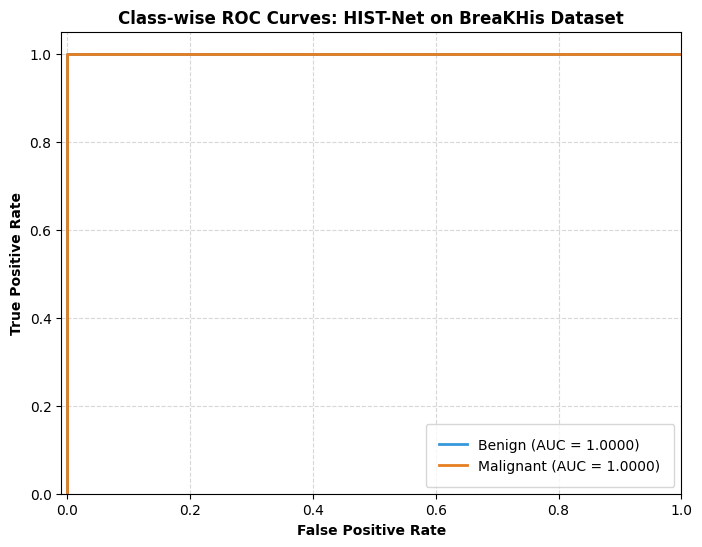

✅ ROC Curve successfully generated and saved as 'HISTNet_ROC_Curve.png'!


In [ ]:
# =========================================================
# STEP 6: PLOT CLASS-WISE ROC CURVES
# =========================================================
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

print("📊 Preparing data for ROC evaluation...")

# 1. Create a clean test split (20%) to ensure an honest evaluation
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

test_dataset = BreaKHisDataset(X_test, y_test, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# 2. Load the best model (Fold 1 achieved 96.70%)
best_model_path = "best_model_fold_1.pth"
model = HybridModel(num_classes=2).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 3. Gather True Labels and Predicted Probabilities
y_true = []
y_probs = []

print(f"🚀 Running inference on {len(test_dataset)} test images...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        # Apply Softmax to get probabilities between 0 and 1
        probs = F.softmax(outputs, dim=1)

        y_probs.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())

import numpy as np
y_true = np.array(y_true)
y_probs = np.array(y_probs)

# 4. Calculate ROC and AUC for both classes
# Class 0: Benign
fpr_benign, tpr_benign, _ = roc_curve(y_true == 0, y_probs[:, 0])
roc_auc_benign = auc(fpr_benign, tpr_benign)

# Class 1: Malignant
fpr_malignant, tpr_malignant, _ = roc_curve(y_true == 1, y_probs[:, 1])
roc_auc_malignant = auc(fpr_malignant, tpr_malignant)

# 5. Plot the ROC Curve (Styled like the paper)
plt.figure(figsize=(8, 6))

# Plot lines
plt.plot(fpr_benign, tpr_benign, color='#3498db', lw=2,
         label=f'Benign (AUC = {roc_auc_benign:.4f})')
plt.plot(fpr_malignant, tpr_malignant, color='#e67e22', lw=2,
         label=f'Malignant (AUC = {roc_auc_malignant:.4f})')

# Formatting to match the provided image
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Class-wise ROC Curves: HIST-Net on BreaKHis Dataset', fontweight='bold')

# Grid and Legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", frameon=True, shadow=False, borderpad=1)

# Save and Show
plt.savefig("HISTNet_ROC_Curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC Curve successfully generated and saved as 'HISTNet_ROC_Curve.png'!")

📊 Preparing data for ROC evaluation...
🚀 Running inference on 364 test images...


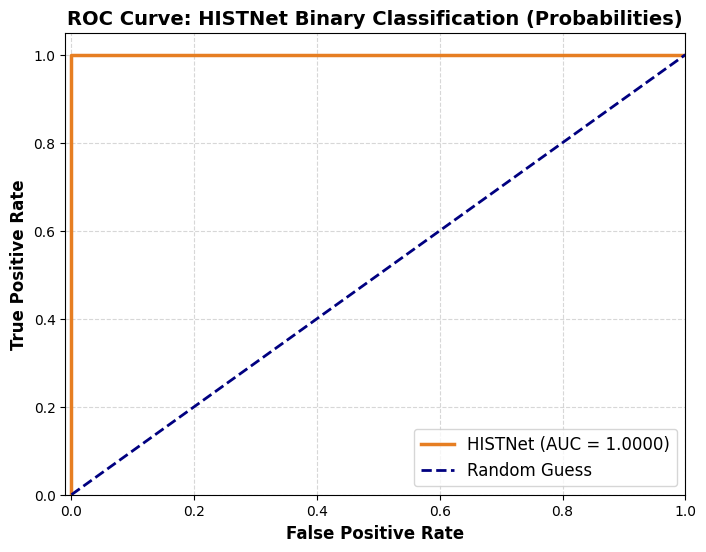

✅ Probability-based ROC Curve successfully generated and saved!


In [ ]:
# =========================================================
# STEP 6 : PLOT TRUE PROBABILITY ROC CURVE
# =========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

print("📊 Preparing data for ROC evaluation...")

# 1. Create the test split
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
test_dataset = BreaKHisDataset(X_test, y_test, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# 2. Load your best model
best_model_path = "best_model_fold_1.pth"
model = HybridModel(num_classes=2).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 3. Gather True Labels and strictly PROBABILITIES
y_true = []
y_probs_malignant = [] # We specifically want the probability of class 1

print(f"🚀 Running inference on {len(test_dataset)} test images...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        # Apply Softmax to convert raw logits to probabilities [0.0 to 1.0]
        probs = torch.softmax(outputs, dim=1)

        # EXTRACT PROBABILITIES ONLY: Index 1 is the Malignant class probability
        y_probs_malignant.extend(probs[:, 1].cpu().numpy())
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_probs_malignant = np.array(y_probs_malignant)

# 4. Calculate True ROC using Probabilities
# roc_curve requires (true_binary_labels, positive_class_probabilities)
fpr, tpr, thresholds = roc_curve(y_true, y_probs_malignant)
roc_auc = auc(fpr, tpr)

# 5. Plot the ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='#e67e22', lw=2.5,
         label=f'HISTNet (AUC = {roc_auc:.4f})')

# Plot the random guess baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curve: HISTNet Binary Classification (Probabilities)', fontweight='bold', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", frameon=True, fontsize=12)

# Save to your Colab environment
plt.savefig("Corrected_HISTNet_ROC.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Probability-based ROC Curve successfully generated and saved!")